# Cognitive Load Research Paper

Extracting EDF parameters from c:\Users\Tony\OneDrive - Universitatea Babeş-Bolyai\Desktop\Metaheuristics Project\data\MAT Dataset\Subject00_1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 90999  =      0.000 ...   181.998 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG Fp2, EEG F3, EEG F4, EEG F7, EEG F8, EEG T3, EEG ...
 chs: 21 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 45.0 Hz
 meas_date: 2011-01-01 00:00:00 UTC
 nchan: 21
 projs: []
 sfreq: 500.0 Hz
 subject_info: <subject_info | his_id: 0, sex: 1, last_name: Subject0, birthday: 1990-01-01>
>


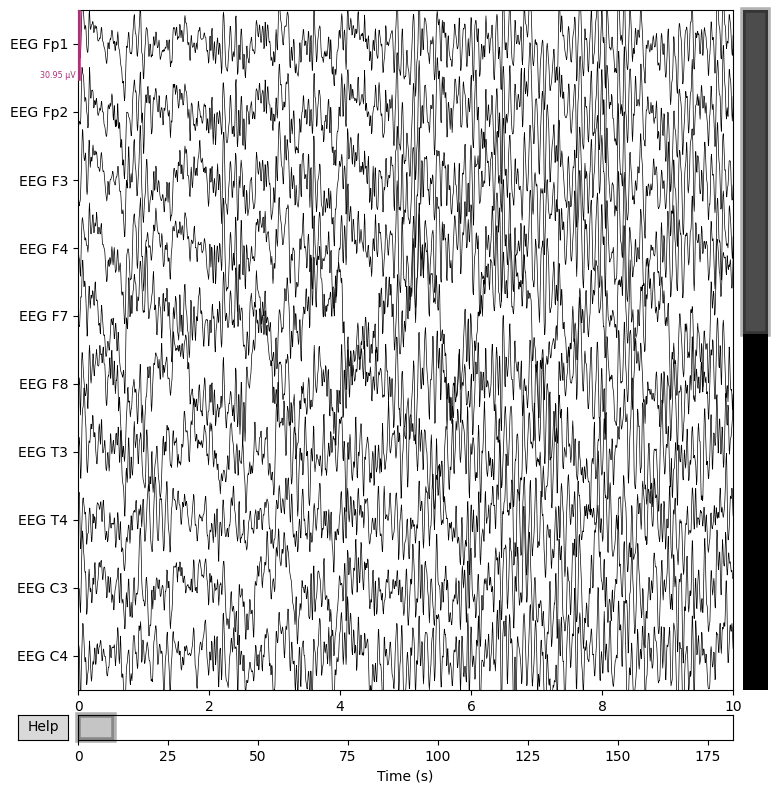

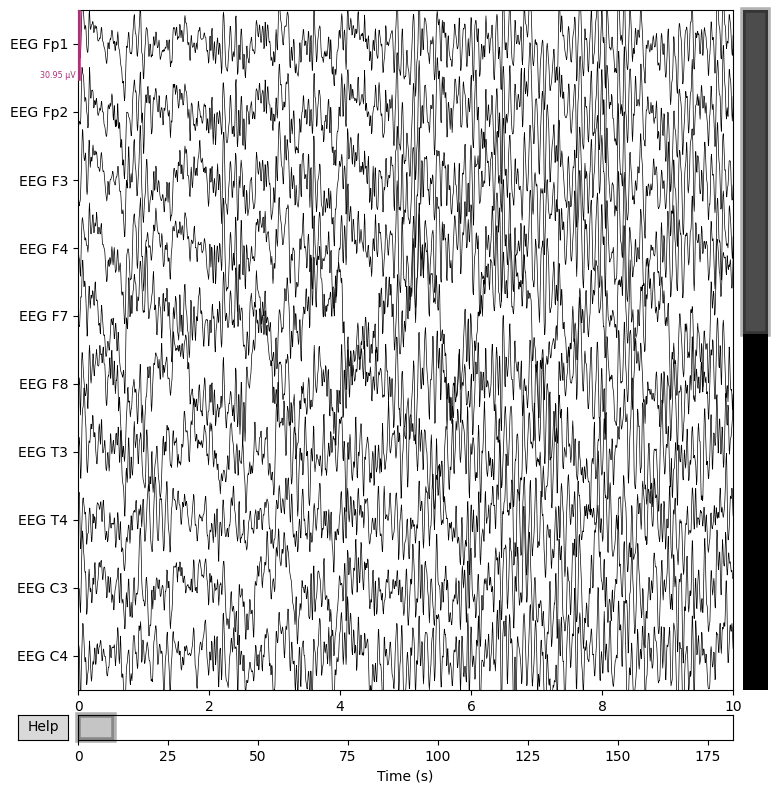

In [ ]:
import mne

raw = mne.io.read_raw_edf('../data/raw/MAT Dataset/Subject00_1.edf', preload=True)

print(raw.info)
raw.plot(n_channels=10, scalings='auto')



In [ ]:
raw.resample(128)  # or 256 if your PC is fast

<RawEDF | Subject00_1.edf, 21 x 23296 (182.0 s), ~3.8 MiB, data loaded>

In [ ]:
raw.filter(1., 40., fir_design='firwin')  # 1-40 Hz range

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 423 samples (3.305 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


<RawEDF | Subject00_1.edf, 21 x 23296 (182.0 s), ~3.8 MiB, data loaded>

### Epcoh the signal

In [ ]:
import numpy as np

# Epoching parameters
epoch_length = 1.0  # seconds
sfreq = raw.info['sfreq']
samples_per_epoch = int(epoch_length * sfreq)

# Get data as NumPy array
data, _ = raw[:, :]
n_channels, n_samples = data.shape

# Calculate number of epochs
n_epochs = n_samples // samples_per_epoch

# Reshape: (n_epochs, n_channels, samples_per_epoch)
epochs = data[:, :n_epochs * samples_per_epoch].reshape(
    n_channels, n_epochs, samples_per_epoch
).transpose(1, 0, 2)  # → (n_epochs, n_channels, time)

print("Epochs shape:", epochs.shape)  # e.g., (120, 14, 128)


Epochs shape: (182, 21, 128)
